In [9]:
%matplotlib inline
import pathlib, pandas as pd, numpy as np, os, gc, warnings, random, torch
warnings.filterwarnings("ignore")

# point this to the parent folder that contains Training/ and Testing/
DATA_ROOT = pathlib.Path(r"C:\Users\Guhan Venkat\AI\Brain Tumor Detector(MRI SCAN)")   # <-- change to your path
print("Looking inside:", DATA_ROOT)

Looking inside: C:\Users\Guhan Venkat\AI\Brain Tumor Detector(MRI SCAN)


In [10]:
labels, paths = [], []
for split in ('Training', 'Testing'):          # whatever top-level folders you have
    for label_dir in (DATA_ROOT/split).iterdir():
        if not label_dir.is_dir():
            continue
        for img_p in label_dir.glob('*'):
            if img_p.suffix.lower() in {'.jpg','.jpeg','.png'}:
                paths.append(str(img_p))
                labels.append(label_dir.name)

df = pd.DataFrame({'image': paths, 'label': labels})
df['label'].value_counts()

label
notumor       2000
pituitary     1757
meningioma    1645
glioma        1621
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df, test_size=0.15, random_state=83, stratify=df['label'])

from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=83)
train_df_os, train_labels_os = ros.fit_resample(
    train_df[['image']], train_df['label'])
train_df = pd.DataFrame({'image': train_df_os['image'].values,
                         'label': train_labels_os})
print('Train:', train_df.shape, 'Test:', test_df.shape)

Train: (6800, 2) Test: (1054, 2)


In [14]:
from datasets import Dataset, Image, ClassLabel
# ── make mapping dict first ----------------------------------
label_list = sorted(df['label'].unique())
label2id   = {l:i for i,l in enumerate(label_list)}
id2label   = {i:l for i,l in enumerate(label_list)}

# ── label mapper (no outside globals) -----------------------
def map_labels(ex):
    ex['label'] = label2id[ex['label']]
    return ex

# ── apply it (single-process to avoid NameError) ------------
train_ds = train_ds.map(map_labels)   # num_proc removed
test_ds  = test_ds.map(map_labels)

Map: 100%|██████████| 1054/1054 [00:00<00:00, 45826.08 examples/s]


In [16]:
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, RandomRotation, RandomAdjustSharpness
from transformers import ViTImageProcessor

processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')
size = processor.size['height']
mean, std = processor.image_mean, processor.image_std

train_tf = Compose([Resize((size,size)), RandomRotation(90), ToTensor(), RandomAdjustSharpness(2), Normalize(mean,std)])
test_tf  = Compose([Resize((size,size)), ToTensor(), Normalize(mean,std)])

def apply_train(batch):
    batch['pixel_values'] = [train_tf(img.convert('RGB')) for img in batch['image']]
    return batch
def apply_test(batch):
    batch['pixel_values'] = [test_tf(img.convert('RGB')) for img in batch['image']]
    return batch

train_ds.set_transform(apply_train)
test_ds.set_transform(apply_test)

In [17]:
def collate(batch):
    pixel_values = torch.stack([ex['pixel_values'] for ex in batch])
    labels = torch.tensor([ex['label'] for ex in batch])
    return {'pixel_values': pixel_values, 'labels': labels}

In [30]:
# !pip install -q fastai
from fastai.vision.all import *

from fastai.vision.all import *

# 1. simple list of absolute paths & labels
imgs = train_df['image'].values
lbls = train_df['label'].values

# 2. DataBlock that treats imgs as already-resolved paths
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=lambda i: imgs[i],   # absolute path → open directly
    get_y=lambda i: lbls[i],
    splitter=RandomSplitter(valid_pct=0.15, seed=83),
    item_tfms=Resize(224),
    batch_tfms=[Rotate(15), Flip(), Normalize.from_stats(*imagenet_stats)]
)

dls = dblock.dataloaders(range(len(imgs)), bs=32)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\Guhan Venkat/.cache\torch\hub\checkpoints\resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:04<00:00, 19.9MB/s]


SuggestedLRs(valley=0.0020892962347716093)

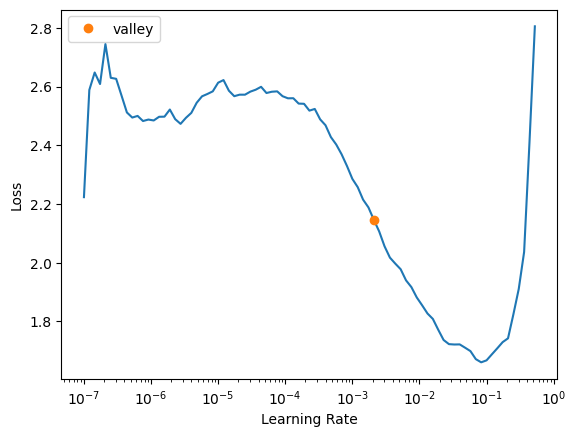

In [31]:
learn = cnn_learner(dls, resnet34, pretrained=True, metrics=accuracy)
learn.lr_find()   # pops plot

Suggested LR ≈ 1.32e+00


Optimal LR ≈ 1.74e-03


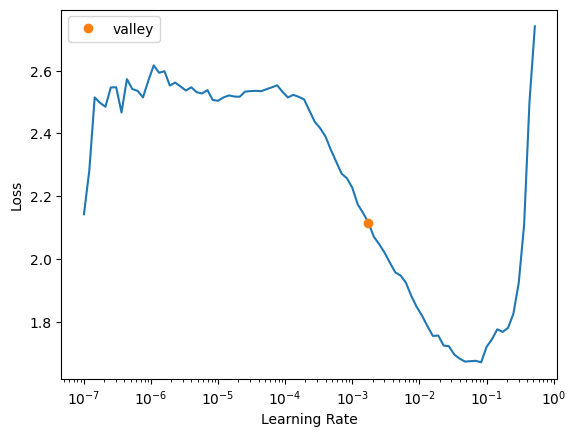

In [35]:
opt_lr = learn.recorder.lrs[-1]             # last value on plot
print(f"Suggested LR ≈ {opt_lr:.2e}")

suggested = learn.lr_find().valley   # gives you the valley LR
print(f"Optimal LR ≈ {suggested:.2e}")

In [37]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224-in21k',
    num_labels=len(label_list),
    id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
from transformers import TrainingArguments

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(1)
    return {
        "accuracy"      : accuracy_score(labels, preds),
        "macro_recall"  : recall_score(labels, preds, average="macro", zero_division=0),
        "weighted_recall":recall_score(labels, preds, average="weighted", zero_division=0),
        "macro_f1"      : f1_score(labels, preds, average="macro", zero_division=0),
    }

training_args = TrainingArguments(
    output_dir="./vit-brain-tumor",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=12,
    learning_rate=4e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_recall",   # monitor recall
    greater_is_better=True,
    fp16=True,
    dataloader_num_workers=0,
    remove_unused_columns=False,
    report_to="none"
)

In [43]:
training_args.learning_rate = suggested      # from FastAI finder
print("Using optimal LR:", training_args.learning_rate)

Using optimal LR: 0.001737800776027143


In [44]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=collate,
    tokenizer=processor,
    compute_metrics=compute_metrics          # <-- use the real one
)

In [45]:
trainer.train()
trainer.evaluate()
trainer.save_model("vit-brain-tumor/best")
processor.save_pretrained("vit-brain-tumor/best")

Epoch,Training Loss,Validation Loss,Accuracy,Macro Recall,Weighted Recall,Macro F1
1,1.093600,1.056841,0.493359,0.470795,0.493359,0.398621
2,1.207200,1.098627,0.501898,0.485901,0.501898,0.471817
3,0.870100,0.830301,0.654649,0.639746,0.654649,0.630375
4,0.689900,1.106727,0.598672,0.592161,0.598672,0.534847
5,0.585000,0.504995,0.788425,0.783405,0.788425,0.784936
6,0.558800,0.395627,0.851992,0.847310,0.851992,0.847060
7,0.492400,0.437333,0.836812,0.832865,0.836812,0.835620
8,0.390700,0.329668,0.884250,0.878374,0.884250,0.878520
9,0.402700,0.304429,0.888046,0.884204,0.888046,0.883494
10,0.295300,0.291563,0.897533,0.892913,0.897533,0.891762


['vit-brain-tumor/best\\preprocessor_config.json']

In [46]:
import os
last_ckpt = sorted(os.listdir("vit-brain-tumor"))[-1]   # e.g. checkpoint-1500
resume_path = f"vit-brain-tumor/{last_ckpt}"
print("Resuming from", resume_path)

Resuming from vit-brain-tumor/checkpoint-852
